In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from edge_detection import *
from line_detection import *
from nfa import validate_lines

In [2]:
path = "../images/pizza.jpg"
img = cv2.imread(path,0)

(np.float64(-0.5), np.float64(1023.5), np.float64(968.5), np.float64(-0.5))

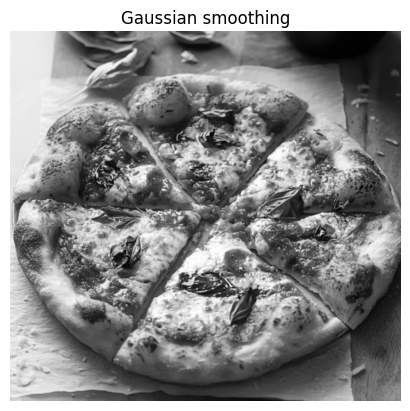

In [3]:
# Gaussian Filter

smooth = gaussian_smoothing(img)

plt.imshow(smooth, cmap="gray")
plt.title("Gaussian smoothing")
plt.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(968.5), np.float64(-0.5))

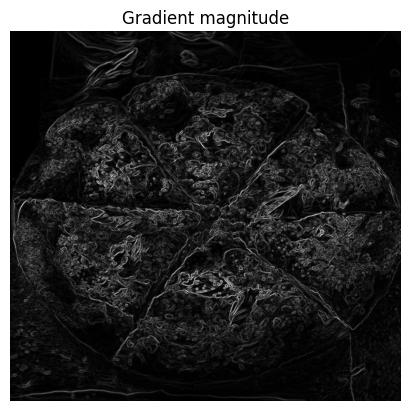

In [4]:
# Gradient computation

smooth = gaussian_smoothing(img)

G, D = compute_gradient(smooth)

plt.imshow(G, cmap="gray")
plt.title("Gradient magnitude")
plt.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(968.5), np.float64(-0.5))

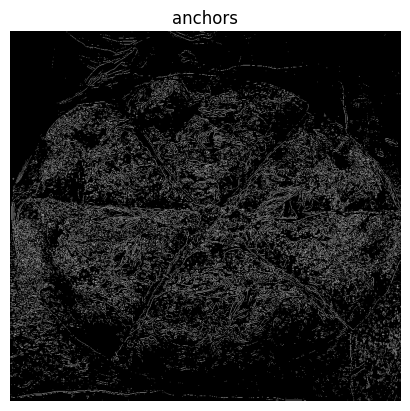

In [13]:
# Anchors computation

anchors = compute_anchors(G, D, anchor_threshold=3)
anchors_img = np.zeros_like(img)

for y, x in anchors:
    anchors_img[y, x] = 255

plt.imshow(anchors_img, cmap="gray")
plt.title("anchors")
plt.axis("off")

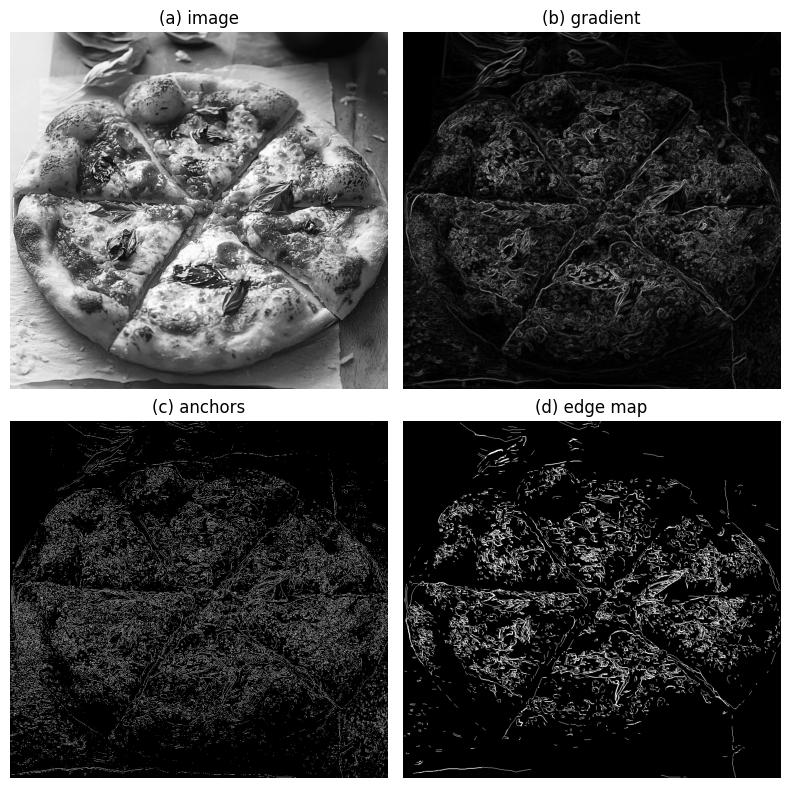

In [14]:
# Edge drawing

edges = edge_drawing(G, D, anchors)
edge_img = np.zeros_like(img)

for edge in edges:
    for y, x in edge:
        edge_img[y, x] = 255

fig, ax = plt.subplots(2,2, figsize=(8,8))

ax[0,0].imshow(img, cmap="gray")
ax[0,0].set_title("(a) image")

ax[0,1].imshow(G, cmap="gray")
ax[0,1].set_title("(b) gradient")

ax[1,0].imshow(anchors_img, cmap="gray")
ax[1,0].set_title("(c) anchors")

ax[1,1].imshow(edge_img, cmap="gray")
ax[1,1].set_title("(d) edge map")

for a in ax.ravel():
    a.axis("off")

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(1023.5), np.float64(968.5), np.float64(-0.5))

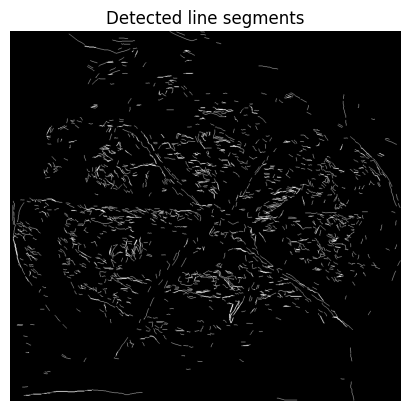

In [15]:
# Detect lines
lines = detect_lines(edges)

line_img = np.zeros_like(img)

for line in lines:
    for y, x in line:
        line_img[y, x] = 255

plt.imshow(line_img, cmap="gray")
plt.title("Detected line segments")
plt.axis("off")

In [23]:
# Valid lines

gx_map = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=1)
gy_map = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=1)

valid_lines = validate_lines(lines, gx_map, gy_map, img.shape, eps=1.0)
print(f"Lignes brutes   : {len(lines)}")
print(f"Lignes valides  : {len(valid_lines)}")

Lignes brutes   : 2232
Lignes valides  : 176


Edges     : 5297
Lignes brutes  : 2232
Lignes valides : 176


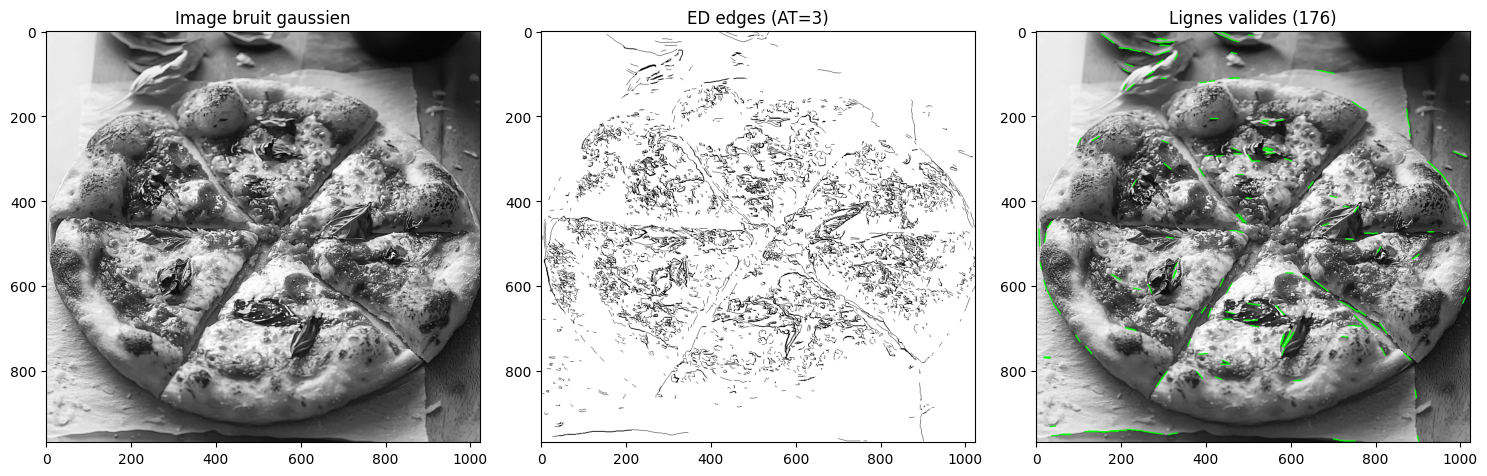

In [24]:
print(f"Edges     : {len(edges)}")
print(f"Lignes brutes  : {len(lines)}")
print(f"Lignes valides : {len(valid_lines)}")  

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Image bruit gaussien")

edge_img = np.ones_like(img) * 255
for edge in edges:
    for y, x in edge:
        edge_img[y, x] = 0
axes[1].imshow(edge_img, cmap='gray')
axes[1].set_title(f"ED edges (AT=3)")


plt.tight_layout()
plt.show()